# CRMLS Exploratory Data Analysis

## SCAN Framework

**Stakeholder Goal:** Understand California single-family home sales and identify the major factors and data issues relevant to predicting `ClosePrice`.

This notebook explores CRMLS sold-property data before preprocessing and modeling.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Data Loading and Initial Inspection

First, load one month of CRMLS data to inspect the dataset structure and available columns.

In [4]:
df_test = pd.read_csv("../data/raw/CRMLSSold202601.csv")

df_test.head()

/var/folders/p3/xl30ms2s591gsby90l48lf4r0000gn/T/ipykernel_17783/2028755234.py:1: DtypeWarning: Columns (4: WaterfrontYN, 74: PostalCode) have mixed types. Specify dtype option on import or set low_memory=False.
  df_test = pd.read_csv("../data/raw/CRMLSSold202601.csv")


,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,LotSizeDimensions,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict
0,Mlslistings,Mlslistings,"Tile,Wood",True,NaN,NaN,NaN,NaN,1151961326,billy@mcnairgroup.com,...,NaN,51219.0,NaN,False,2.0,Other,94062,NaN,51219.0,NaN
1,BeverlyHillsGreaterLa,BeverlyHillsGreaterLa,"Tile,Vinyl,Wood",True,NaN,NaN,False,4000.0,1151961163,realtorjasonp@gmail.com,...,NaN,13496.0,NaN,False,2.0,NaN,90004,NaN,13496.0,NaN
2,Delta,Delta,Laminate,NaN,NaN,NaN,False,2975000.0,1151959385,LoriAbreu10@gmail.com,...,NaN,238186.0,NaN,False,0.0,NaN,94517,NaN,238186.0,NaN
3,SouthBay,SouthBay,"Tile,Wood",False,NaN,NaN,False,1340000.0,1151952151,jen@jencaskeygroup.com,...,NaN,4970.0,0.0,False,2.0,Redondo Unified,90278,0.0,4970.0,NaN
4,OrangeCounty,OrangeCounty,NaN,True,NaN,NaN,False,720000.0,1151944067,aaronguzmanre@gmail.com,...,NaN,8224.0,2.0,False,2.0,El Monte Union High,91770,0.0,8224.0,NaN


In [5]:
print("Rows:", df_test.shape[0])
print("Columns:", df_test.shape[1])

df_test.columns.tolist()

Rows: 16487
Columns: 78


['BuyerAgentAOR',
 'ListAgentAOR',
 'Flooring',
 'ViewYN',
 'WaterfrontYN',
 'BasementYN',
 'PoolPrivateYN',
 'OriginalListPrice',
 'ListingKey',
 'ListAgentEmail',
 'CloseDate',
 'ClosePrice',
 'ListAgentFirstName',
 'ListAgentLastName',
 'Latitude',
 'Longitude',
 'UnparsedAddress',
 'PropertyType',
 'LivingArea',
 'ListPrice',
 'DaysOnMarket',
 'ListOfficeName',
 'BuyerOfficeName',
 'CoListOfficeName',
 'ListAgentFullName',
 'CoListAgentFirstName',
 'CoListAgentLastName',
 'BuyerAgentMlsId',
 'BuyerAgentFirstName',
 'BuyerAgentLastName',
 'FireplacesTotal',
 'AssociationFeeFrequency',
 'AboveGradeFinishedArea',
 'ListingKeyNumeric',
 'MLSAreaMajor',
 'TaxAnnualAmount',
 'CountyOrParish',
 'MlsStatus',
 'ElementarySchool',
 'AttachedGarageYN',
 'ParkingTotal',
 'BuilderName',
 'PropertySubType',
 'LotSizeAcres',
 'SubdivisionName',
 'BuyerOfficeAOR',
 'YearBuilt',
 'StreetNumberNumeric',
 'ListingId',
 'BathroomsTotalInteger',
 'City',
 'TaxYear',
 'BuildingAreaTotal',
 'BedroomsTota

In [6]:
key_columns = [
    'ClosePrice',
    'LivingArea',
    'BedroomsTotal',
    'BathroomsTotalInteger',
    'LotSizeSquareFeet',
    'PropertyType',
    'PropertySubType'
]

df_test[key_columns].head(10)

,ClosePrice,LivingArea,BedroomsTotal,BathroomsTotalInteger,LotSizeSquareFeet,PropertyType,PropertySubType
0,11706000.0,4636.0,4.0,6.0,51219.0,Residential,SingleFamilyResidence
1,4000.0,1250.0,3.0,2.0,13496.0,ResidentialLease,Condominium
2,2975000.0,1600.0,2.0,1.0,238186.0,Residential,SingleFamilyResidence
3,1340000.0,1702.0,3.0,2.0,4970.0,Residential,Townhouse
4,720000.0,937.0,2.0,1.0,8224.0,Residential,SingleFamilyResidence
5,600000.0,1267.0,3.0,1.0,6716.0,Residential,SingleFamilyResidence
6,850000.0,NaN,NaN,NaN,5663.0,ResidentialIncome,Duplex
7,1750000.0,1637.0,3.0,3.0,NaN,Residential,Townhouse
8,15991988.0,1920.0,4.0,4.0,3670.0,Residential,SingleFamilyResidence
9,3636725.0,3185.0,4.0,4.0,8750.0,Residential,SingleFamilyResidence


## 2. Multi-Month Data Preparation

Load the CRMLS monthly sold-property datasets, combine them into a single DataFrame, and restrict the analysis to residential single-family homes.

In [7]:
from pathlib import Path

data_path = Path("../data/raw")

csv_files = sorted(data_path.glob("CRMLSSold*.csv"))

print("Number of files found:", len(csv_files))

for file in csv_files:
    print(file.name)


Number of files found: 27
CRMLSSold202401_filled.csv
CRMLSSold202402.csv
CRMLSSold202403_filled.csv
CRMLSSold202404_filled.csv
CRMLSSold202405_filled.csv
CRMLSSold202406_filled.csv
CRMLSSold202407_filled.csv
CRMLSSold202408.csv
CRMLSSold202409.csv
CRMLSSold202410.csv
CRMLSSold202411.csv
CRMLSSold202412.csv
CRMLSSold202501_filled.csv
CRMLSSold202502.csv
CRMLSSold202503.csv
CRMLSSold202504.csv
CRMLSSold202505.csv
CRMLSSold202506.csv
CRMLSSold202507.csv
CRMLSSold202508.csv
CRMLSSold202509.csv
CRMLSSold202510.csv
CRMLSSold202511.csv
CRMLSSold202512.csv
CRMLSSold202601.csv
CRMLSSold202602.csv
CRMLSSold202603.csv


In [8]:
dataframes = []

for file in csv_files:
    monthly_df = pd.read_csv(file, low_memory=False)

    # Extract the month from the filename
    month = file.stem.replace("CRMLSSold", "").replace("_filled", "")
    monthly_df["DataMonth"] = month

    dataframes.append(monthly_df)

df = pd.concat(dataframes, ignore_index=True)

print("Combined rows:", df.shape[0])
print("Combined columns:", df.shape[1])

Combined rows: 591446
Combined columns: 85


In [9]:
df[["DataMonth", "ClosePrice", "PropertyType", "PropertySubType"]].head()


,DataMonth,ClosePrice,PropertyType,PropertySubType
0,202401,240000.0,Residential,Condominium
1,202401,950.0,CommercialLease,Retail
2,202401,45000.0,Land,NaN
3,202401,141500.0,Land,NaN
4,202401,15000.0,Land,NaN


In [10]:
df["DataMonth"].value_counts().sort_index()

DataMonth
202401    17958
202402    19925
202403    23276
202404    24640
202405    26487
202406    24328
202407    26240
202408    24558
202409    21267
202410    23274
202411    20279
202412    20241
202501    18738
202502    18702
202503    21445
202504    23262
202505    23154
202506    22883
202507    23646
202508    22972
202509    22443
202510    23233
202511    19088
202512    20538
202601    16487
202602    19010
202603    23372
Name: count, dtype: int64

### Filter to Residential Single-Family Homes

For this analysis, restrict the combined dataset to properties where `PropertyType` is `Residential` and `PropertySubType` is `SingleFamilyResidence`.

In [11]:
df_sfr = df[
    (df["PropertyType"] == "Residential") &
    (df["PropertySubType"] == "SingleFamilyResidence")
].copy()

print("Rows before filtering:", len(df))
print("Rows after filtering:", len(df_sfr))
print("Percent retained:", round(len(df_sfr) / len(df) * 100, 2), "%")

Rows before filtering: 591446
Rows after filtering: 297245
Percent retained: 50.26 %


In [12]:
print(df_sfr["PropertyType"].value_counts())
print()
print(df_sfr["PropertySubType"].value_counts())

PropertyType
Residential    297245
Name: count, dtype: int64

PropertySubType
SingleFamilyResidence    297245
Name: count, dtype: int64


## 3. Aggregates and Anomalies

Examine the distributions, summary statistics, missing values, duplicates, and potential anomalies in the key variables for residential single-family homes.

In [13]:
print("Total single-family home sales:", len(df_sfr))
print("Number of months:", df_sfr["DataMonth"].nunique())

df_sfr["DataMonth"].value_counts().sort_index()

Total single-family home sales: 297245
Number of months: 27


DataMonth
202401     8322
202402     9564
202403    11634
202404    12745
202405    13831
202406    12545
202407    13378
202408    12433
202409    10909
202410    12347
202411    10692
202412    10624
202501     8144
202502     8851
202503    10610
202504    11880
202505    11777
202506    11701
202507    12114
202508    11454
202509    11456
202510    12029
202511     9739
202512    10455
202601     7490
202602     8959
202603    11562
Name: count, dtype: int64

### Summary Statistics

Start by examining the overall distributions of the primary numeric variables related to home characteristics and sale price.

In [14]:
numeric_columns = [
    "ClosePrice",
    "LivingArea",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "LotSizeSquareFeet"
]

pd.options.display.float_format = '{:,.2f}'.format

df_sfr[numeric_columns].describe()

,ClosePrice,LivingArea,BedroomsTotal,BathroomsTotalInteger,LotSizeSquareFeet
count,"297,243.00","297,084.00","297,245.00","297,195.00","292,160.00"
mean,"1,289,639.68","2,032.83",3.48,2.62,"273,887.84"
std,"5,252,026.01","1,059.81",0.96,1.20,"14,869,913.90"
min,0.00,0.00,0.00,0.00,0.00
25%,"625,000.00","1,376.00",3.00,2.00,"5,663.00"
50%,"890,000.00","1,802.00",3.00,2.00,"7,245.00"
75%,"1,430,000.00","2,420.00",4.00,3.00,"10,341.00"
max,"989,500,000.00","123,764.00",45.00,175.00,"2,087,220,960.00"


**Initial observations:**
- `ClosePrice` is right-skewed: the mean is higher than the median.
- All five variables contain zero values, which should be investigated.
- There are extremely large maximum values for price, living area, bedrooms, bathrooms, and lot size.
- These potential anomalies should be investigated before deciding how to clean the data.

### Close Price Distribution

Examine the distribution of `ClosePrice`. First visualize the raw data to assess the effect of extreme values, then restrict the visualization to the 0.5th–99.5th percentile range to better view the underlying distribution.

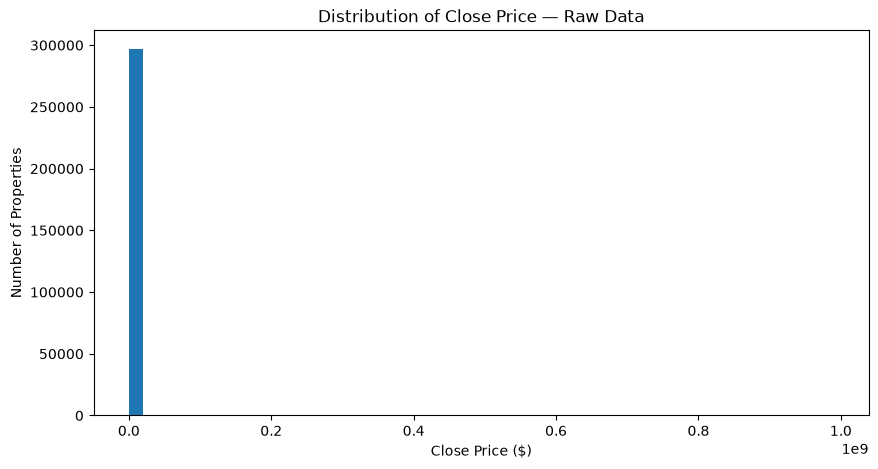

In [15]:
plt.figure(figsize=(10, 5))

plt.hist(df_sfr["ClosePrice"].dropna(), bins=50)

plt.xlabel("Close Price ($)")
plt.ylabel("Number of Properties")
plt.title("Distribution of Close Price — Raw Data")

plt.show()

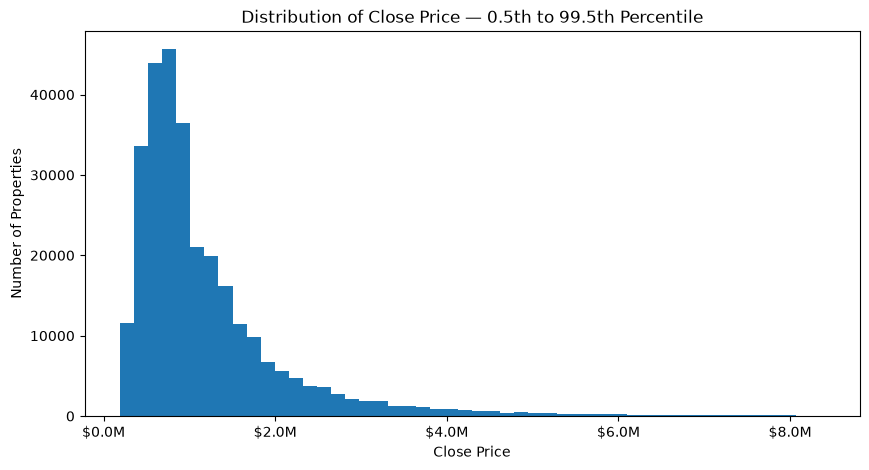

0.5th percentile: $190,000
99.5th percentile: $8,400,000


In [16]:
from matplotlib.ticker import FuncFormatter

price_lower = df_sfr["ClosePrice"].quantile(0.005)
price_upper = df_sfr["ClosePrice"].quantile(0.995)

price_plot = df_sfr[
    df_sfr["ClosePrice"].between(price_lower, price_upper)
]

plt.figure(figsize=(10, 5))
plt.hist(price_plot["ClosePrice"].dropna(), bins=50)

plt.xlabel("Close Price")
plt.ylabel("Number of Properties")
plt.title("Distribution of Close Price — 0.5th to 99.5th Percentile")

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"${x/1_000_000:.1f}M")
)

plt.show()

print(f"0.5th percentile: ${price_lower:,.0f}")
print(f"99.5th percentile: ${price_upper:,.0f}")

**ClosePrice observations:**
- The raw distribution is heavily affected by extreme high-price observations, including values approaching $1 billion.
- After restricting the visualization to the 0.5th–99.5th percentile range, the underlying distribution is much clearer.
- `ClosePrice` remains strongly right-skewed, with most sales concentrated at lower price levels and a long tail of higher-priced homes.
- The percentile restriction is used only for visualization; no observations have been removed from the analysis dataset.

### Missing Values

Check how frequently the key variables are missing before deciding how missing observations should be handled during preprocessing.

In [17]:
missing_summary = pd.DataFrame({
    "MissingCount": df_sfr[numeric_columns].isna().sum(),
    "MissingPercent": df_sfr[numeric_columns].isna().mean() * 100
})

missing_summary.sort_values("MissingPercent", ascending=False)

,MissingCount,MissingPercent
LotSizeSquareFeet,5085,1.71
LivingArea,161,0.05
BathroomsTotalInteger,50,0.02
ClosePrice,2,0.00
BedroomsTotal,0,0.00


**Missing value observations:**
- Missingness is relatively low across the key variables.
- `LotSizeSquareFeet` has the most missing data, with 5,085 missing observations (1.71%).
- `LivingArea` and `BathroomsTotalInteger` have very little missing data.
- `BedroomsTotal` has no missing values, while `ClosePrice` is missing for only 2 observations.
- Missing values will be addressed during preprocessing rather than removed during EDA.

### Zero and Non-Positive Values

Examine zero and negative values in the key numeric variables, since these may represent unusual properties, missing-value conventions, or data-quality issues.

In [18]:
non_positive_summary = pd.DataFrame({
    "ZeroCount": (df_sfr[numeric_columns] == 0).sum(),
    "NegativeCount": (df_sfr[numeric_columns] < 0).sum()
})

non_positive_summary

,ZeroCount,NegativeCount
ClosePrice,1,0
LivingArea,121,0
BedroomsTotal,173,0
BathroomsTotalInteger,128,0
LotSizeSquareFeet,151,0


**Zero/non-positive value observations:**
- No negative values were found in the key numeric variables.
- A small number of records contain zero values for price and property characteristics.
- These records should be treated as potential data-quality issues and evaluated during preprocessing.

### Property Characteristic Distributions

Examine the distributions of living area, bedrooms, bathrooms, and lot size. Percentile-based ranges are used for continuous variables to prevent extreme observations from obscuring the main distributions.

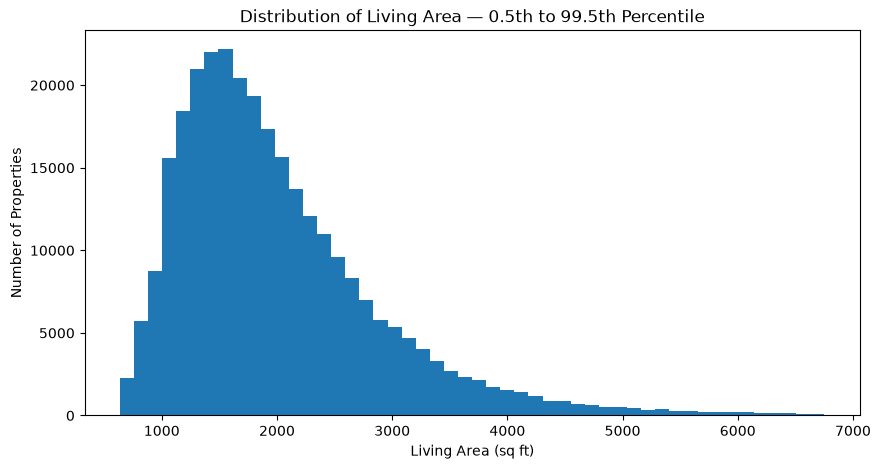

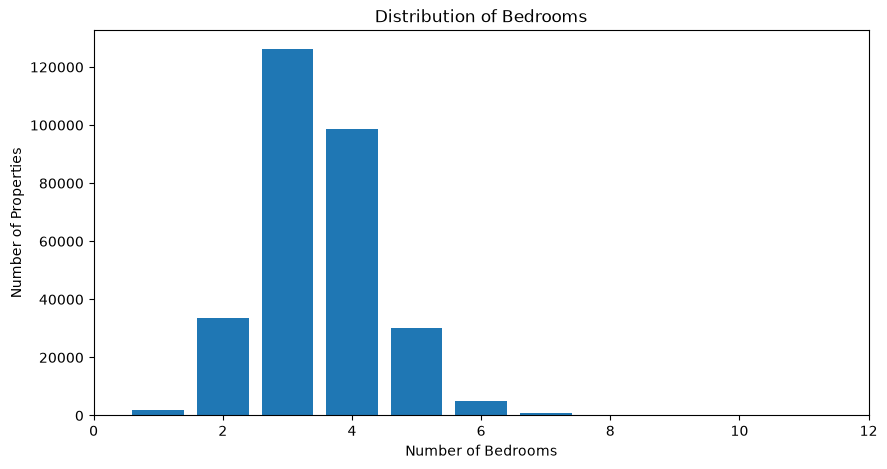

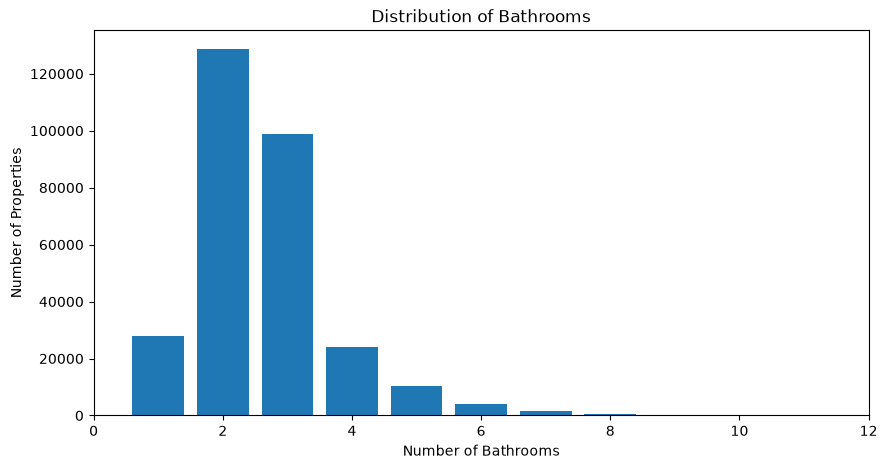

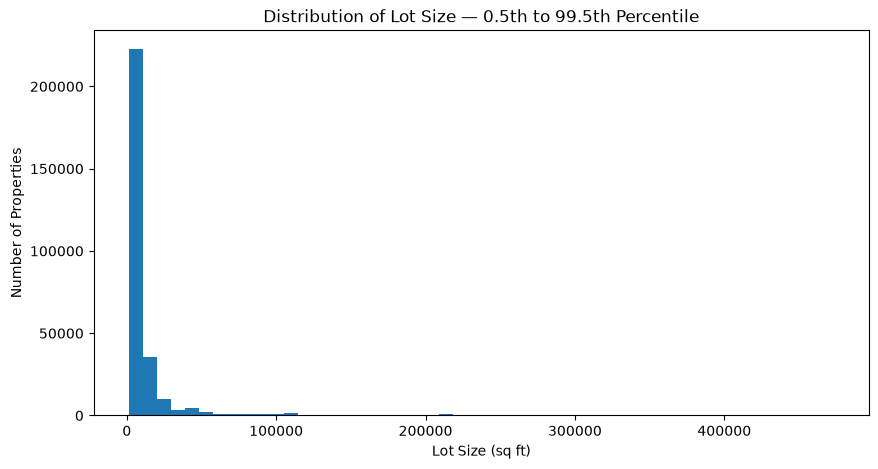

In [19]:
# Living Area — middle 99%
living_lower = df_sfr["LivingArea"].quantile(0.005)
living_upper = df_sfr["LivingArea"].quantile(0.995)

plt.figure(figsize=(10, 5))
plt.hist(
    df_sfr["LivingArea"]
    .loc[df_sfr["LivingArea"].between(living_lower, living_upper)]
    .dropna(),
    bins=50
)
plt.xlabel("Living Area (sq ft)")
plt.ylabel("Number of Properties")
plt.title("Distribution of Living Area — 0.5th to 99.5th Percentile")
plt.show()


# Bedrooms
bedroom_counts = df_sfr["BedroomsTotal"].value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.bar(bedroom_counts.index, bedroom_counts.values)
plt.xlim(0, 12)
plt.xlabel("Number of Bedrooms")
plt.ylabel("Number of Properties")
plt.title("Distribution of Bedrooms")
plt.show()


# Bathrooms
bathroom_counts = df_sfr["BathroomsTotalInteger"].value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.bar(bathroom_counts.index, bathroom_counts.values)
plt.xlim(0, 12)
plt.xlabel("Number of Bathrooms")
plt.ylabel("Number of Properties")
plt.title("Distribution of Bathrooms")
plt.show()


# Lot Size — middle 99%
lot_lower = df_sfr["LotSizeSquareFeet"].quantile(0.005)
lot_upper = df_sfr["LotSizeSquareFeet"].quantile(0.995)

plt.figure(figsize=(10, 5))
plt.hist(
    df_sfr["LotSizeSquareFeet"]
    .loc[df_sfr["LotSizeSquareFeet"].between(lot_lower, lot_upper)]
    .dropna(),
    bins=50
)
plt.xlabel("Lot Size (sq ft)")
plt.ylabel("Number of Properties")
plt.title("Distribution of Lot Size — 0.5th to 99.5th Percentile")
plt.show()

**Property characteristic observations:**
- Living area is right-skewed, with most single-family homes concentrated below roughly 3,000 square feet.
- Three- and four-bedroom homes make up the largest share of the dataset.
- Two- and three-bathroom homes are the most common.
- Lot size is highly right-skewed, with a relatively small number of properties having very large lots.
- These distributions suggest that several continuous features may require outlier handling during preprocessing.

### Duplicate Records

In [20]:
print("Exact duplicate rows:", df_sfr.duplicated().sum())

print(
    "Duplicate ListingKeys:",
    df_sfr["ListingKey"].duplicated().sum()
)

Exact duplicate rows: 29
Duplicate ListingKeys: 258


**Duplicate observations:**
- 29 exact duplicate rows were identified.
- 258 rows have duplicated `ListingKey` values.
- Repeated listing keys will be investigated before determining whether they represent true duplicate transactions.

## 4. Notable Segments and Price Relationships

Examine how `ClosePrice` varies with major property characteristics, time, and geography to identify potentially useful predictors.

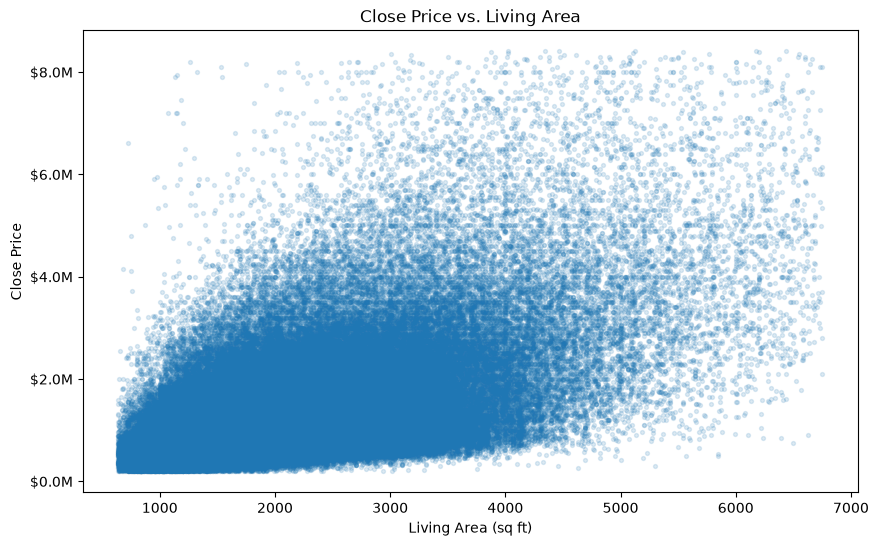

In [21]:
relationship_df = df_sfr[
    df_sfr["ClosePrice"].between(
        df_sfr["ClosePrice"].quantile(0.005),
        df_sfr["ClosePrice"].quantile(0.995)
    )
    &
    df_sfr["LivingArea"].between(
        df_sfr["LivingArea"].quantile(0.005),
        df_sfr["LivingArea"].quantile(0.995)
    )
]

plt.figure(figsize=(10, 6))

plt.scatter(
    relationship_df["LivingArea"],
    relationship_df["ClosePrice"],
    alpha=0.15,
    s=8
)

plt.xlabel("Living Area (sq ft)")
plt.ylabel("Close Price")
plt.title("Close Price vs. Living Area")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"${x/1_000_000:.1f}M")
)

plt.show()

**Living Area vs. Close Price observations:**
- `LivingArea` shows a clear positive relationship with `ClosePrice`: larger homes generally sell for higher prices.
- Price variation increases substantially for larger homes.
- Homes with similar living areas can have very different sale prices, suggesting that other factors such as location, lot size, and property characteristics are also important predictors.
- `LivingArea` therefore appears to be a useful feature for the eventual price prediction model, but it is not sufficient on its own.

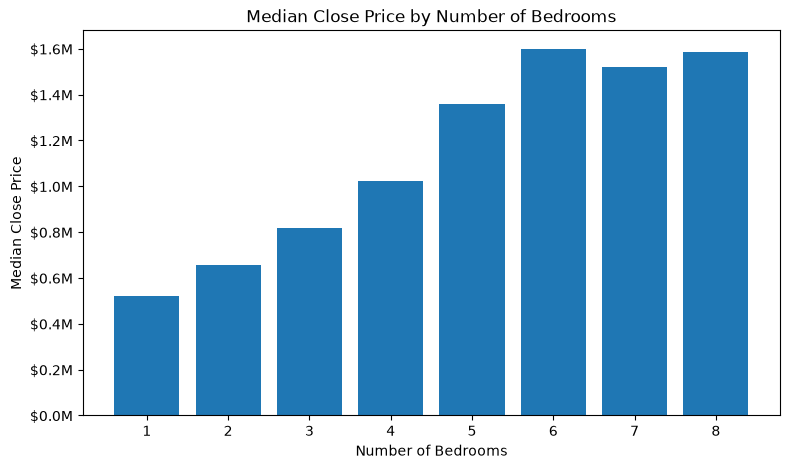

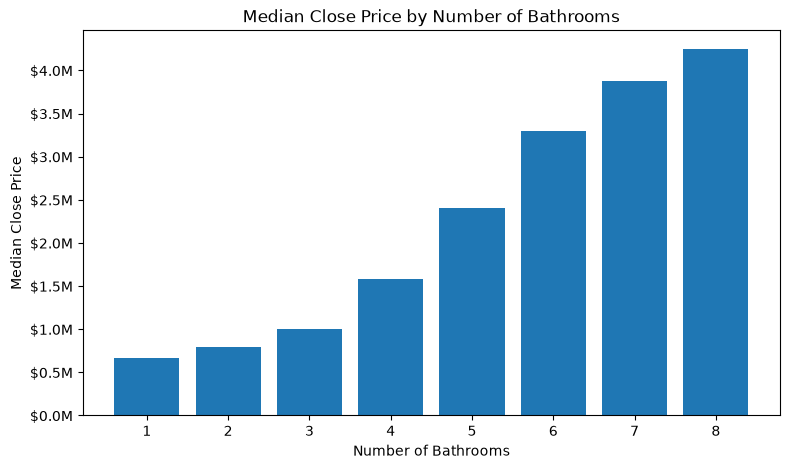

In [22]:
# Median close price by number of bedrooms
bedroom_price = (
    relationship_df[
        relationship_df["BedroomsTotal"].between(1, 8)
    ]
    .groupby("BedroomsTotal")["ClosePrice"]
    .median()
)

plt.figure(figsize=(9, 5))
plt.bar(bedroom_price.index, bedroom_price.values)

plt.xlabel("Number of Bedrooms")
plt.ylabel("Median Close Price")
plt.title("Median Close Price by Number of Bedrooms")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"${x/1_000_000:.1f}M")
)

plt.show()


# Median close price by number of bathrooms
bathroom_price = (
    relationship_df[
        relationship_df["BathroomsTotalInteger"].between(1, 8)
    ]
    .groupby("BathroomsTotalInteger")["ClosePrice"]
    .median()
)

plt.figure(figsize=(9, 5))
plt.bar(bathroom_price.index, bathroom_price.values)

plt.xlabel("Number of Bathrooms")
plt.ylabel("Median Close Price")
plt.title("Median Close Price by Number of Bathrooms")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"${x/1_000_000:.1f}M")
)

plt.show()

### Lot Size vs. Close Price

Examine whether larger lot sizes are associated with higher sale prices.

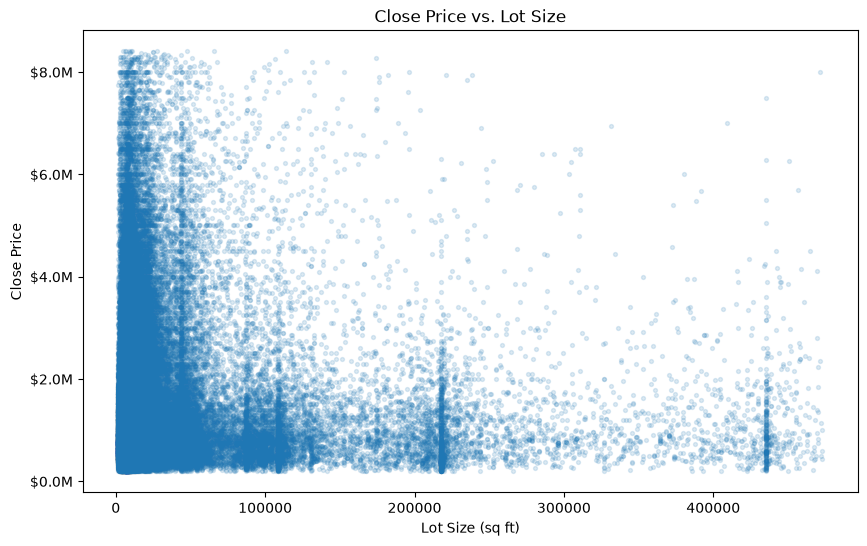

In [23]:
lot_lower = df_sfr["LotSizeSquareFeet"].quantile(0.005)
lot_upper = df_sfr["LotSizeSquareFeet"].quantile(0.995)

lot_relationship = df_sfr[
    df_sfr["LotSizeSquareFeet"].between(lot_lower, lot_upper)
    &
    df_sfr["ClosePrice"].between(price_lower, price_upper)
]

plt.figure(figsize=(10, 6))

plt.scatter(
    lot_relationship["LotSizeSquareFeet"],
    lot_relationship["ClosePrice"],
    alpha=0.15,
    s=8
)

plt.xlabel("Lot Size (sq ft)")
plt.ylabel("Close Price")
plt.title("Close Price vs. Lot Size")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"${x/1_000_000:.1f}M")
)

plt.show()

**Lot Size vs. Close Price observations:**
- Unlike `LivingArea`, `LotSizeSquareFeet` does not show a strong, clear relationship with `ClosePrice`.
- High-priced homes occur across a wide range of lot sizes, including relatively small lots.
- Very large lots also span a wide range of sale prices, suggesting that lot size alone is not a strong predictor of price.
- Distinct concentrations appear around certain large lot sizes, which may reflect properties recorded in whole-acre increments or standardized conversions.
- The relationship may depend strongly on location and property type characteristics.

### Geographic Differences in Close Price

Compare typical sale prices across high-volume cities to determine whether
location appears important for price prediction.

In [24]:
geo_columns = [
    "City",
    "PostalCode",
    "CountyOrParish",
    "MLSAreaMajor"
]

for col in geo_columns:
    if col in df_sfr.columns:
        print(
            col,
            "| Unique:", df_sfr[col].nunique(),
            "| Missing:", round(df_sfr[col].isna().mean() * 100, 2), "%"
        )

City | Unique: 1099 | Missing: 0.08 %
PostalCode | Unique: 3109 | Missing: 0.0 %
CountyOrParish | Unique: 63 | Missing: 0.0 %
MLSAreaMajor | Unique: 1069 | Missing: 14.19 %


In [25]:
city_counts = df_sfr["City"].value_counts()

top_cities = city_counts.head(15).index

city_summary = (
    df_sfr[df_sfr["City"].isin(top_cities)]
    .groupby("City")
    .agg(
        Sales=("ClosePrice", "count"),
        MedianClosePrice=("ClosePrice", "median")
    )
    .sort_values("MedianClosePrice")
)

city_summary

,Sales,MedianClosePrice
City,,
Victorville,2834,"440,000.00"
Hemet,2627,"453,000.00"
Lancaster,2842,"480,000.00"
San Bernardino,2555,"506,000.00"
Moreno Valley,2431,"560,000.00"
Menifee,3305,"587,000.00"
Riverside,4563,"675,000.00"
Murrieta,2595,"701,177.00"
Corona,2800,"785,000.00"


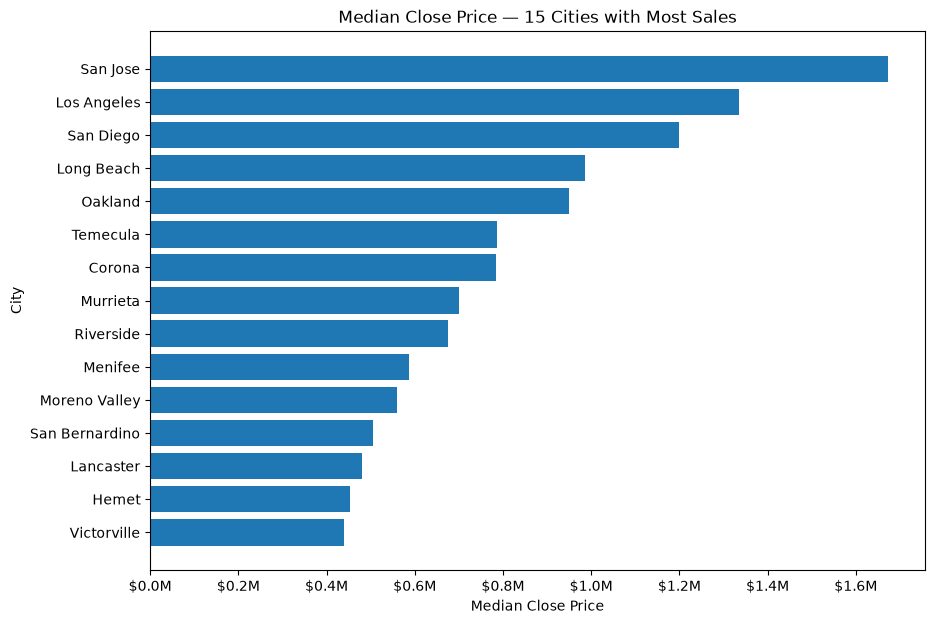

In [26]:
plt.figure(figsize=(10, 7))

plt.barh(
    city_summary.index,
    city_summary["MedianClosePrice"]
)

plt.xlabel("Median Close Price")
plt.ylabel("City")
plt.title("Median Close Price — 15 Cities with Most Sales")

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"${x/1_000_000:.1f}M")
)

plt.show()

**Geographic observations:**
- Median sale prices vary substantially across the highest-volume cities.
- Among these cities, median prices range from approximately $440,000 in Victorville to $1.67 million in San Jose.
- The large differences across cities suggest that geographic location is likely an important predictor of `ClosePrice`.
- Geographic variables such as `City` and `PostalCode` should therefore be considered during feature engineering and modeling.

### Close Price Over Time

Examine median sale price by month to identify temporal patterns in the housing data.

In [29]:
monthly_summary = (
    df_sfr
    .groupby("DataMonth")
    .agg(
        Sales=("ClosePrice", "count"),
        MedianClosePrice=("ClosePrice", "median")
    )
    .sort_index()
)

monthly_summary

,Sales,MedianClosePrice
DataMonth,,
202401,8322,"799,000.00"
202402,9564,"860,000.00"
202403,11634,"880,000.00"
202404,12745,"928,000.00"
202405,13831,"935,000.00"
202406,12544,"935,000.00"
202407,13378,"925,000.00"
202408,12433,"900,000.00"
202409,10909,"890,000.00"


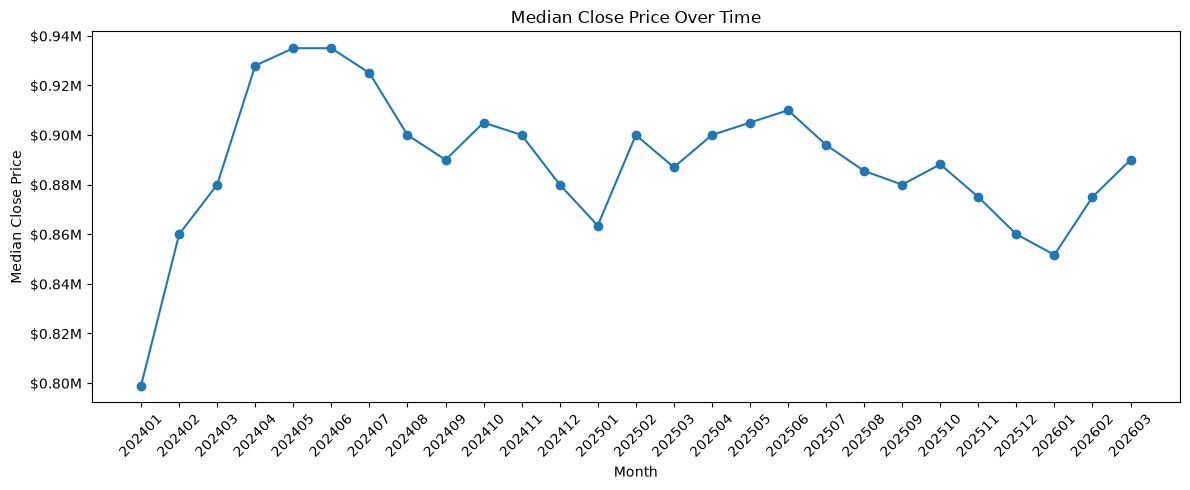

In [30]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_summary.index,
    monthly_summary["MedianClosePrice"],
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Median Close Price")
plt.title("Median Close Price Over Time")

plt.xticks(rotation=45)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"${x/1_000_000:.2f}M")
)

plt.tight_layout()
plt.show()

**Time observations:**
- Median close prices vary meaningfully across the 27 months in the dataset.
- Prices increased sharply during the first half of 2024, reaching approximately $935,000 in May and June before declining later in the year.
- Similar within-year variation appears in 2025, with median prices rising into the middle of the year and declining toward the end.
- These patterns suggest that sale timing may contain useful predictive information, although additional years would be needed to establish a consistent seasonal pattern.
- A chronological train/test split should be considered during modeling so that the model is evaluated on future transactions rather than randomly mixed observations.

## 5. EDA Summary and Key Findings

The exploratory analysis identified several important characteristics of the CRMLS single-family residential sales data:

- The combined dataset contains 27 months of CRMLS records from January 2024 through March 2026, with approximately 297,000 single-family residential transactions after filtering.
- `ClosePrice` is strongly right-skewed and contains extreme values, indicating that unrealistic or highly unusual observations should be investigated during preprocessing.
- Small numbers of zero values occur in important variables including `ClosePrice`, `LivingArea`, bedrooms, bathrooms, and lot size.
- Missingness is relatively low among the primary numeric variables, although `LotSizeSquareFeet` has more missing observations than the other core features.
- Living area shows a clear positive relationship with sale price, while lot size has a much weaker and noisier relationship.
- Sale prices differ substantially across cities, indicating that geographic location is likely to be an important predictor.
- Median sale prices also vary over time, suggesting that temporal information should be considered and that chronological model evaluation may be preferable to a random train/test split.
- Duplicate records and duplicate `ListingKey` values were identified and should be investigated during preprocessing.

These findings will guide the preprocessing and feature-selection decisions used in the next stage of the project.